In [2]:
# import
import pandas as pd
import numpy as np
from collections import defaultdict, deque
import matplotlib.pyplot as plt

# load ontology branch
cancer_terms = set(pd.read_csv("data/cancer_terms.csv")["mondo_id"])
edges_df = pd.read_csv("data/cancer_model_edges.csv")

ROOT = "MONDO_0004992"

parents = defaultdict(set)
children = defaultdict(set)

for _, row in edges_df.iterrows():
    child = row["child"]
    parent = row["parent"]
    if child in cancer_terms and parent in cancer_terms:
        parents[child].add(parent)
        children[parent].add(child)

print("Cancer terms:", len(cancer_terms))
print("Cancer edges:", edges_df.shape[0])

# depth map
cancer_terms = set(pd.read_csv("data/cancer_terms.csv")["mondo_id"])
edges_df = pd.read_csv("data/cancer_model_edges.csv")

ROOT = "MONDO_0004992"

parents = defaultdict(set)
children = defaultdict(set)

for _, row in edges_df.iterrows():
    child = row["child"]
    parent = row["parent"]
    if child in cancer_terms and parent in cancer_terms:
        parents[child].add(parent)
        children[parent].add(child)

print("Cancer terms:", len(cancer_terms))
print("Cancer edges:", edges_df.shape[0])

# ancestor helper
def ancestors(term):
    out = set()
    stack = list(parents.get(term, []))
    while stack:
        x = stack.pop()
        if x not in out:
            out.add(x)
            stack.extend(parents.get(x, []))
    return out

Cancer terms: 2270
Cancer edges: 382
Cancer terms: 2270
Cancer edges: 382


In [3]:
# load prediction
def load_all_preds(fp):
    df = pd.read_csv(fp)
    df["mondo_id"] = df["model"].str.replace("__preds", "", regex=False)
    return df

human_all = load_all_preds("results/meta/human_title_summary_preds.csv")
mouse_all = load_all_preds("results/meta/mouse_title_summary_preds.csv")

human_all = human_all[human_all["mondo_id"].isin(cancer_terms)].copy()
mouse_all = mouse_all[mouse_all["mondo_id"].isin(cancer_terms)].copy()

print("Human all cancer preds:", human_all.shape)
print("Mouse all cancer preds:", mouse_all.shape)

# strong hits
THRESH = 1.0

def build_topk_hits(all_df, thresh):
    df = all_df[all_df["log2(prob/prior)"] >= thresh].copy()
    hit_map = df.groupby("ID")["mondo_id"].apply(set).to_dict()
    return df, hit_map

human_topk, human_hit_map = build_topk_hits(human_all, THRESH)
mouse_topk, mouse_hit_map = build_topk_hits(mouse_all, THRESH)

print("Human Top-k rows:", human_topk.shape)
print("Mouse Top-k rows:", mouse_topk.shape)
print("Human IDs:", human_topk["ID"].nunique())
print("Mouse IDs:", mouse_topk["ID"].nunique())

Human all cancer preds: (886095, 6)
Mouse all cancer preds: (1061226, 6)
Human Top-k rows: (6997, 6)
Mouse Top-k rows: (2650, 6)
Human IDs: 982
Mouse IDs: 472


In [4]:
# direct parent hit rate
def direct_parent_consistency(topk_df, hit_map, name):
    rows = []

    for _, row in topk_df.iterrows():
        gse_id = row["ID"]
        child = row["mondo_id"]

        direct_parents = [p for p in parents.get(child, set()) if p in cancer_terms]
        if not direct_parents:
            continue

        hits = hit_map.get(gse_id, set())

        for p in direct_parents:
            rows.append({
                "ID": gse_id,
                "child": child,
                "parent": p,
                "parent_hit": p in hits
            })

    out = pd.DataFrame(rows)

    print(f"\n--- {name}: direct parent-hit ---")
    print("Rows:", len(out))
    print("Parent-hit rate:", out["parent_hit"].mean())

    return out

human_parent = direct_parent_consistency(human_topk, human_hit_map, "Human")
mouse_parent = direct_parent_consistency(mouse_topk, mouse_hit_map, "Mouse")


--- Human: direct parent-hit ---
Rows: 9710
Parent-hit rate: 0.6925849639546859

--- Mouse: direct parent-hit ---
Rows: 3683
Parent-hit rate: 0.6228617974477328


In [5]:
# ancestor coverage
def ancestor_coverage(topk_df, hit_map, name):
    rows = []

    for _, row in topk_df.iterrows():
        gse_id = row["ID"]
        term = row["mondo_id"]

        anc = {a for a in ancestors(term) if a in cancer_terms}
        if len(anc) == 0:
            continue

        hits = hit_map.get(gse_id, set())
        anc_hit = anc & hits

        rows.append({
            "ID": gse_id,
            "term": term,
            "depth": depth.get(term, np.nan),
            "coverage": len(anc_hit) / len(anc),
            "n_ancestors": len(anc),
            "n_ancestors_hit": len(anc_hit)
        })

    out = pd.DataFrame(rows)

    print(f"\n--- {name}: ancestor coverage ---")
    print("Rows:", len(out))
    print("Mean coverage:", out["coverage"].mean())
    print("Median coverage:", out["coverage"].median())

    return out

human_cov = ancestor_coverage(human_topk, human_hit_map, "Human")
mouse_cov = ancestor_coverage(mouse_topk, mouse_hit_map, "Mouse")


--- Human: ancestor coverage ---
Rows: 6997
Mean coverage: 0.46972714730682436
Median coverage: 0.5

--- Mouse: ancestor coverage ---
Rows: 2650
Mean coverage: 0.42552904380734563
Median coverage: 0.5


In [6]:
# coverage by depth
def summarize_coverage_by_depth(cov_df, name):
    summary = cov_df.groupby("depth")["coverage"].agg(["count", "mean", "median"]).reset_index()
    print(f"\n--- {name}: coverage by depth ---")
    print(summary)
    return summary

human_cov_depth = summarize_coverage_by_depth(human_cov, "Human")
mouse_cov_depth = summarize_coverage_by_depth(mouse_cov, "Mouse")


--- Human: coverage by depth ---
   depth  count      mean    median
0      1   1425  0.000000  0.000000
1      2   2241  0.485126  0.500000
2      3   1932  0.626153  0.666667
3      4   1227  0.701204  0.666667
4      5    171  0.753858  0.857143
5      6      1  0.500000  0.500000

--- Mouse: coverage by depth ---
   depth  count      mean    median
0      1    572  0.000000  0.000000
1      2    878  0.449553  0.500000
2      3    818  0.572674  0.625000
3      4    295  0.657236  0.750000
4      5     86  0.810183  0.857143
5      6      1  0.937500  0.937500


In [7]:
# edge level monotonicity
def edge_monotonicity(all_df, topk_df, name):
    score_map = all_df.set_index(["ID", "mondo_id"])["log2(prob/prior)"].to_dict()
    rows = []

    for _, row in topk_df.iterrows():
        gse_id = row["ID"]
        child = row["mondo_id"]
        child_score = row["log2(prob/prior)"]

        direct_parents = [p for p in parents.get(child, set()) if p in cancer_terms]
        if not direct_parents:
            continue

        for p in direct_parents:
            parent_score = score_map.get((gse_id, p), np.nan)
            if pd.isna(parent_score):
                continue

            delta = child_score - parent_score
            rows.append({
                "ID": gse_id,
                "child": child,
                "parent": p,
                "child_score": child_score,
                "parent_score": parent_score,
                "delta": delta,
                "child_gt_parent": delta > 0
            })

    out = pd.DataFrame(rows)

    print(f"\n--- {name}: edge monotonicity ---")
    print("Rows:", len(out))
    print("Mean delta:", out["delta"].mean())
    print("Median delta:", out["delta"].median())
    print("child > parent rate:", out["child_gt_parent"].mean())

    return out

human_edge = edge_monotonicity(human_all, human_topk, "Human")
mouse_edge = edge_monotonicity(mouse_all, mouse_topk, "Mouse")


--- Human: edge monotonicity ---
Rows: 9710
Mean delta: 0.47301440442708975
Median delta: 0.1881710827792139
child > parent rate: 0.6319258496395469

--- Mouse: edge monotonicity ---
Rows: 3683
Mean delta: 0.6265575781604965
Median delta: 0.2209997277679313
child > parent rate: 0.6972576703774097


In [8]:
# threshold sensitivity
def run_threshold_metrics(all_df, label):
    out = []

    for t in [1.0, 1.5, 2.0]:
        topk_df, hit_map = build_topk_hits(all_df, t)
        parent_df = direct_parent_consistency(topk_df, hit_map, f"{label}@{t}")
        cov_df = ancestor_coverage(topk_df, hit_map, f"{label}@{t}")

        out.append({
            "threshold": t,
            "n_ids": topk_df["ID"].nunique(),
            "mean_hits_per_id": topk_df.groupby("ID")["mondo_id"].nunique().mean(),
            "parent_hit_rate": parent_df["parent_hit"].mean(),
            "ancestor_coverage_mean": cov_df["coverage"].mean()
        })

    return pd.DataFrame(out)

human_threshold_summary = run_threshold_metrics(human_all, "Human")
mouse_threshold_summary = run_threshold_metrics(mouse_all, "Mouse")

print("\nHuman threshold summary")
print(human_threshold_summary)

print("\nMouse threshold summary")
print(mouse_threshold_summary)


--- Human@1.0: direct parent-hit ---
Rows: 9710
Parent-hit rate: 0.6925849639546859

--- Human@1.0: ancestor coverage ---
Rows: 6997
Mean coverage: 0.46972714730682436
Median coverage: 0.5

--- Human@1.5: direct parent-hit ---
Rows: 6807
Parent-hit rate: 0.6530042603202586

--- Human@1.5: ancestor coverage ---
Rows: 4908
Mean coverage: 0.4448570417855258
Median coverage: 0.5

--- Human@2.0: direct parent-hit ---
Rows: 4702
Parent-hit rate: 0.6161207996597192

--- Human@2.0: ancestor coverage ---
Rows: 3405
Mean coverage: 0.42407876916687487
Median coverage: 0.5

--- Mouse@1.0: direct parent-hit ---
Rows: 3683
Parent-hit rate: 0.6228617974477328

--- Mouse@1.0: ancestor coverage ---
Rows: 2650
Mean coverage: 0.42552904380734563
Median coverage: 0.5

--- Mouse@1.5: direct parent-hit ---
Rows: 2359
Parent-hit rate: 0.6146672318779144

--- Mouse@1.5: ancestor coverage ---
Rows: 1724
Mean coverage: 0.4263756746282848
Median coverage: 0.5

--- Mouse@2.0: direct parent-hit ---
Rows: 1526
Par

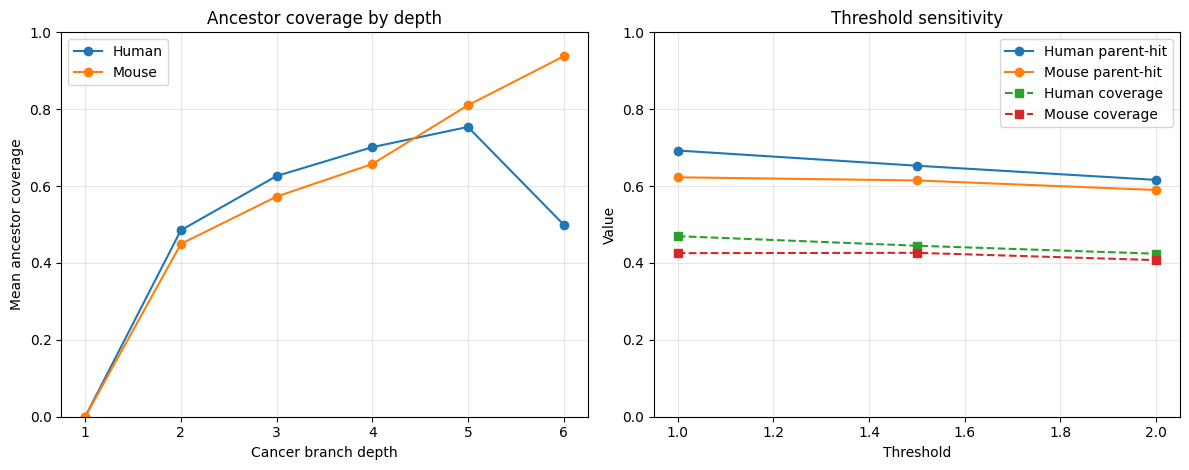

In [9]:
# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax1, ax2 = axes

ax1.plot(human_cov_depth["depth"], human_cov_depth["mean"], marker="o", label="Human")
ax1.plot(mouse_cov_depth["depth"], mouse_cov_depth["mean"], marker="o", label="Mouse")
ax1.set_title("Ancestor coverage by depth")
ax1.set_xlabel("Cancer branch depth")
ax1.set_ylabel("Mean ancestor coverage")
ax1.set_ylim(0, 1.0)
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(human_threshold_summary["threshold"], human_threshold_summary["parent_hit_rate"], marker="o", label="Human parent-hit")
ax2.plot(mouse_threshold_summary["threshold"], mouse_threshold_summary["parent_hit_rate"], marker="o", label="Mouse parent-hit")
ax2.plot(human_threshold_summary["threshold"], human_threshold_summary["ancestor_coverage_mean"], marker="s", linestyle="--", label="Human coverage")
ax2.plot(mouse_threshold_summary["threshold"], mouse_threshold_summary["ancestor_coverage_mean"], marker="s", linestyle="--", label="Mouse coverage")
ax2.set_title("Threshold sensitivity")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Value")
ax2.set_ylim(0, 1.0)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# export
human_parent.to_csv("results/core_human_parent_hit.csv", index=False)
mouse_parent.to_csv("results/core_mouse_parent_hit.csv", index=False)

human_cov.to_csv("results/core_human_ancestor_coverage.csv", index=False)
mouse_cov.to_csv("results/core_mouse_ancestor_coverage.csv", index=False)

human_edge.to_csv("results/core_human_edge_monotonicity.csv", index=False)
mouse_edge.to_csv("results/core_mouse_edge_monotonicity.csv", index=False)

human_threshold_summary.to_csv("results/core_human_threshold_summary.csv", index=False)
mouse_threshold_summary.to_csv("results/core_mouse_threshold_summary.csv", index=False)